In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from bio_optics.models import bandratioIOPprediction
# from bio_optics.processors.simIOPs_Hyperspectral_multipleOWT_smallFile_20251211 import iop_insitu # this might be an automatic generated line which is simply wrong!

# PhytoMix Developments - native-hyperspectral

See presentation Z:\projects\ongoing\AQUATIME\sharepoint\WP3 Product Engineering\InversionPhytoplanktonGroups\PhytoMix_Dev_20260902.pptx

- Training data generation: Full inversion bio_optics is better with adjusted start values! (Previous result). Is this still true? Reuse the simple algorithms (based on GLORIA insitu data)
- EnMAP extraction and preparation: compare AC land and AC water for the same pixels. Compare with S2-MSI. Can we derive some functionality for teh overcorrected water spectra?
- PACE preparation: Overcorrected spectra: find a better offset-correction! (Use OLCI data as reference?)
- Bridging (satellite to simulations): Rethink the PCA part! Can we train noisy spectra to 1nm simulation spectra, directly? How?
- Phytoplankton-Conc product / Training:
    - How do we combine the results of different groups into one product?
    - Comparison of total_conc for each product - combine, mean?
    - Set conc=0, if too small.
    - Optical closure? Idea: use all necessary features from phytoplankton groups, train one model for all components, total phyto, CDOM, TSS simultaneously. Use forward model and add the reconstruction error to the cost function.
    - Add the estimated start values from the hyperspectral linear model as input parameters!

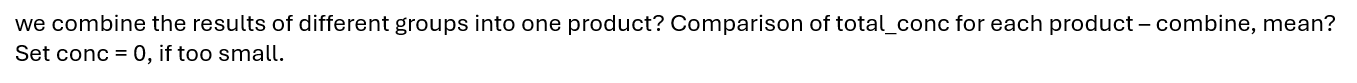

## Training data generation: Influence of start values

### Original concentrations

In [4]:
## original concentrations
metaDict = {
    'dalaro-2': {'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\dalaro-2\\",
        'datasetName': 'CHIME_sim_AQUATIME_dalaro-2',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\IOPs\Case Study 2 - Dalarö\\',
        'datasetNameIOP': 'dalaro_dalaro_v0.3_daily',
        'lat': 59.128,
        'lon': 18.411,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold'
                 },
    'pyhajarvi': {'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\pyhajarvi\\",
        'datasetName' :'CHIME_sim_AQUATIME_pyhajarvi',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\IOPs\Case Study 3 pyhajarvi\\',
        'datasetNameIOP': 'pyhajarvi_continuous_v0.3',
        'lat': 61.025460552597494,
        'lon': 22.205154164905377,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                  },
    'elbe_bunthaus' : {'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\elbe_bunthaus\\",
        'datasetName' : 'CHIME_sim_AQUATIME_elbe_bunthaus',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 elbe_bunthaus\\',
        'datasetNameIOP': 'elbe-river_bunthaus_v0.3',
        'lat': 53.461787,
        'lon': 10.064451,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                       },
    'elbe_seemannshöft' :{'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\elbe_seemannshöft\\",
        'datasetName': 'CHIME_sim_AQUATIME_elbe-seemannshöft',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 elbe_seemannshöft\\',
        'datasetNameIOP': 'elbe-river_seemannshöft_v0.3',
        'lat': 53.540068,
        'lon': 9.885823,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                           },
    'oder_frankfurt': {'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\oder_frankfurt\\",
        'datasetName': 'CHIME_sim_AQUATIME_oder_frankfurt',
        'iop_path': 'Z:\projects\\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Oder_Frankfurt\\',
        'datasetNameIOP': 'oder-river_frankfurt_v0.3',
        'lat': 52.357381058811875,
        'lon': 14.55155726803013,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                       },
    'oder_hohenwutzen': { 'project': 'AQUATIME',
        'path': "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\oder_hohenwutzen\\",
        'datasetName': 'CHIME_sim_AQUATIME_oder_hohenwutzen',
        'iop_path': 'Z:\projects\\ongoing\AQUATIME\\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Oder_Hohenwutzen\\',
        'datasetNameIOP': 'oder-river_hohenwutzen_v0.3',
        'lat': 52.83612915898216,
        'lon': 14.122788786414537,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
                         },
    'vortsjarv': {# no inversion available yet!
        'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\pyhajarvi\\",
        'datasetName' :'CHIME_sim_AQUATIME_pyhajarvi',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Vörtsjärv\\',
        'datasetNameIOP': 'vortsjarv',
        'lat': 58.2111,
        'lon': 26.10556,
        'specNAP_variable': True,
        'PhytoGroupSet' : 'HEREONgold'
    },
    'uto' : { 'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\pyhajarvi\\",
        'datasetName' :'CHIME_sim_AQUATIME_pyhajarvi',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 4 Utö\\',
        'datasetNameIOP': 'uto_continuous_v0.3',
        'lat': 59.7788,
        'lon': 21.3558,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold'},
    'malaren' : { 'project': 'AQUATIME',
        'path' : "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\Simulated Spectra\malaren-gorvaln\\",
        'datasetName' :'CHIME_sim_AQUATIME_malaren',
        'iop_path': 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Mälären\\',
        'datasetNameIOP': 'malaren_gorvaln_daily_v0.3',
        'lat': 59.4321,
        'lon': 17.76425,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold'
    },
    'belgian_coast_RT1': { 'project': 'AQUATIME',
        'lat': 51.2464,
        'lon': 2.9193
       },
    'belgian_coast_CPOWER': { 'project': 'AQUATIME',
        'lat': 51.532,
        'lon': 2.955
    },
    'Helsinki_SS': {'project': 'HEATWISE',
        'path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\",
        'datasetName': '',
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Helsinki\input_simulations\\",
        'datasetNameIOP': "helsinki_silja_serenade_IOP_v0.2", # 'helsinki_silja_serenade_daily_v0.3',
        'lat': 60.15,
        'lon': 25.00,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
    },
    'Helsinki_FM': { 'project': 'HEATWISE',
        'path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\",
        'datasetName': '',
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Helsinki\input_simulations\\",
        'datasetNameIOP': 'helsinki_finnmaid_daily_v0.3',
        'lat': 60.19,
        'lon': 25.213,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREON'
    },
    'muggelsee': { 'project': 'HEATWISE',
        'path' : "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\",
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\input_simulations\\",
        'datasetNameIOP': "berlin_muggelsee_IOP_daily_v0.3.", #"berlin_muggelsee_IOP_daily_v0.3_SZA_Gx_OZA2"
        'lat': 52.4373,
        'lon': 13.6474,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold'
        },
    'EnMAPSuperpixel':{
        'project': 'EnMAPSuperpixel',
        'PhytoGroupSet': 'HEREON',
        'iop_path': None,
        'specNAP_variable': False
    }
}


# Define wavelength range and sampling rate
# wavelengths=np.arange(400.,900., 1.)
## CHIME central wavelengths
wavelengths = np.array((404.2, 412.6, 421. , 429.4, 437.8, 446.2, 454.6, 463. , 471.4,
       479.8, 488.2, 496.6, 505. , 513.4, 521.8, 530.2, 538.6, 547. ,
       555.4, 563.8, 572.2, 580.6, 589. , 597.4, 605.8, 614.2, 622.6,
       631. , 639.4, 647.8, 656.2, 664.6, 673. , 681.4, 689.8, 698.2,
       706.6, 715. , 723.4, 731.8, 740.2, 748.6, 757. , 765.4, 773.8,
       782.2, 790.6, 799. , 807.4, 815.8, 824.2, 832.6, 841. , 849.4,
       857.8, 866.2, 874.6, 883. , 891.4, 899.8, 908.2, 916.6, 925. ,
       933.4, 941.8, 950.2, 958.6, 967. , 975.4, 983.8, 992.2))

In [5]:
regionName = 'muggelsee' #'muggelsee' #'dalaro-2'
iop_path = metaDict[regionName]['iop_path']
datasetNameIOP = metaDict[regionName]['datasetNameIOP']

fname = os.listdir(iop_path)
iop_insitu_fname = [fn for fn in fname if fn.startswith(datasetNameIOP) and 'v0.3' in fn][0] # Silja Serenade v0.2 # Helsinki: 'IOP' in fn and ... 'v0.2'
print(iop_insitu_fname)
iop_insitu = pd.read_csv(iop_path+ iop_insitu_fname, sep=',')

berlin_muggelsee_IOP_daily_v0.3.csv


In [6]:
iop_insitu.columns.values

<ArrowStringArray>
[               'datetime',                 'Temp °C',
          'Salinity [PSU]',             'Chlg [µg/l]',
              'Cgr [µg/l]',             'Ckie [µg/l]',
              'Cbl [µg/l]',             'Cbl2 [µg/l]',
             'Ccry [µg/l]',            'Cgold [µg/l]',
            'Cdino [µg/l]',           'ag(440) [1/m]',
               'Sg [1/nm]',             'TSPM [mg/l]',
              'NAP [mg/l]', 'anap_spec(440) [m2 g-1]',
             'Snap [1/nm]',        'latitude_station',
       'longitude_station',           'latitude_cams',
          'longitude_cams',                     'u10',
                     'v10',                'bcaod550',
                'duaod550',                'omaod550',
                'ssaod550',                  'aod469',
                  'aod550',                  'aod670',
                  'aod865',                 'aod1240',
                  'tc_ch4',                   'gtco3',
                    'tcwv']
Length: 35, dtype:

In [7]:
iop_insitu['datetime'] = pd.to_datetime(iop_insitu['datetime'])
iop_insitu = iop_insitu.set_index('datetime')

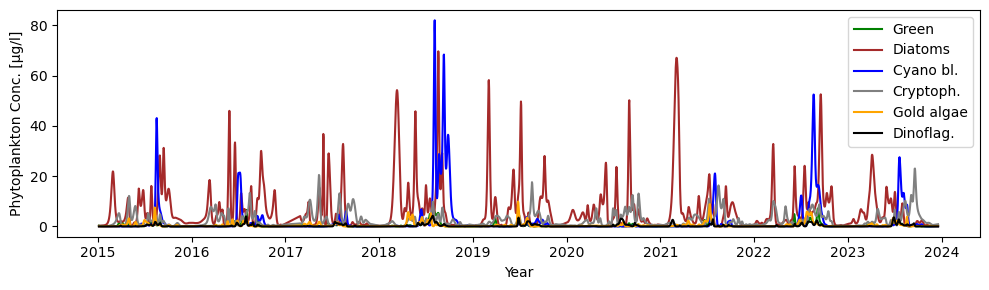

In [8]:
varList = ['Cgr [µg/l]',  'Ckie [µg/l]','Cbl [µg/l]',  'Cbl2 [µg/l]','Ccry [µg/l]',  'Cgold [µg/l]','Cdino [µg/l]']
varNameList = ['Green',  'Diatoms','Cyano bl.',  'Cyano red', 'Cryptoph.', 'Gold algae','Dinoflag.']
colorList = ['green', 'brown', 'blue', 'red', 'grey', 'orange', 'black']

fig, ax = plt.subplots(figsize=(10, 3))
for v,vn, col in zip(varList, varNameList, colorList):
    if any(iop_insitu[v]>0):
        ax.plot(iop_insitu[v], '-', label=vn, color=col)
ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Phytoplankton Conc. [µg/l]')
fig.tight_layout()
plt.show()

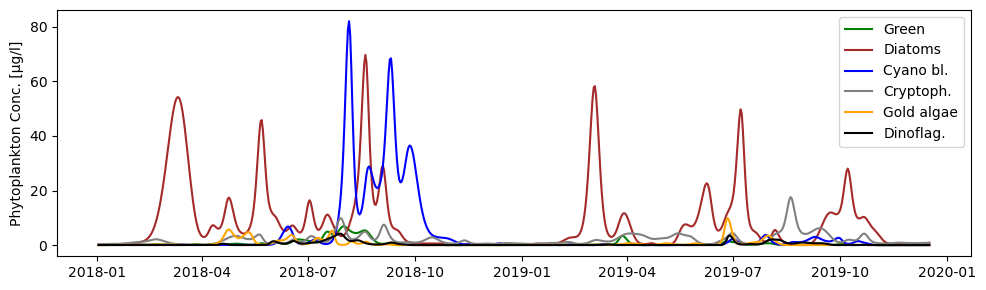

In [31]:
varList = ['Cgr [µg/l]',  'Ckie [µg/l]','Cbl [µg/l]',  'Cbl2 [µg/l]','Ccry [µg/l]',  'Cgold [µg/l]','Cdino [µg/l]']
varNameList = ['Green',  'Diatoms','Cyano bl.',  'Cyano red', 'Cryptoph.', 'Gold algae','Dinoflag.']
colorList = ['green', 'brown', 'blue', 'red', 'grey', 'orange', 'black']

yearStart = 2018
yearEnd = 2019
years = np.asarray([a.year for a in iop_insitu.index])
IDyear = np.logical_and(years>=yearStart, years<=yearEnd)

fig, ax = plt.subplots(figsize=(10, 3))
for v,vn, col in zip(varList, varNameList, colorList):
    if any(iop_insitu[v]>0):
        ax.plot(iop_insitu[v].loc[IDyear], '-', label=vn, color=col)
ax.legend()
# ax.set_xlabel('Year')
ax.set_ylabel('Phytoplankton Conc. [µg/l]')
fig.tight_layout()
plt.show()

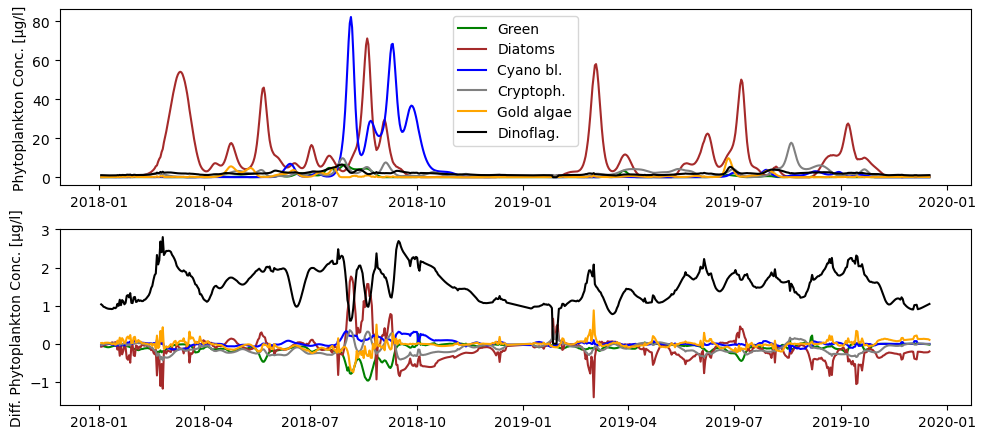

In [45]:
## plot the inversion timeseries!
varList = ['Cgr [µg/l]',  'Ckie [µg/l]','Cbl [µg/l]',  'Cbl2 [µg/l]','Ccry [µg/l]',  'Cgold [µg/l]','Cdino [µg/l]']
invList = ['C_1', 'C_0', 'C_3', 'C_4', 'C_2', 'C_5', 'C_6']
varNameList = ['Green',  'Diatoms','Cyano bl.',  'Cyano red', 'Cryptoph.', 'Gold algae','Dinoflag.']
colorList = ['green', 'brown', 'blue', 'red', 'grey', 'orange', 'black']

yearStart = 2018
yearEnd = 2019
years = np.asarray([a.year for a in iop_insitu.index])
IDyear = np.logical_and(years>=yearStart, years<=yearEnd)

fig, ax = plt.subplots(nrows=2, figsize=(10, 4.5))
for v,vn, col, ivn in zip(varList, varNameList, colorList, invList):
    if any(iop_insitu[v]>0):
        # ax.plot(iop_insitu[v].loc[IDyear], '-', color='gray', alpha=0.5)
        ax[0].plot(iop_insitu.index[IDyear], inv_iop[ivn].loc[IDyear], '-', label=vn, color=col)
        ax[1].plot(iop_insitu.index[IDyear], (inv_iop[ivn].loc[IDyear].values -iop_insitu[v].loc[IDyear].values), '-', label=vn, color=col)
ax[0].legend()
# ax.set_xlabel('Year')
ax[0].set_ylabel('Phytoplankton Conc. [µg/l]')
ax[1].set_ylabel('Diff. Phytoplankton Conc. [µg/l]')
# ax[1].set_ylim((-50,50))
fig.tight_layout()
plt.show()

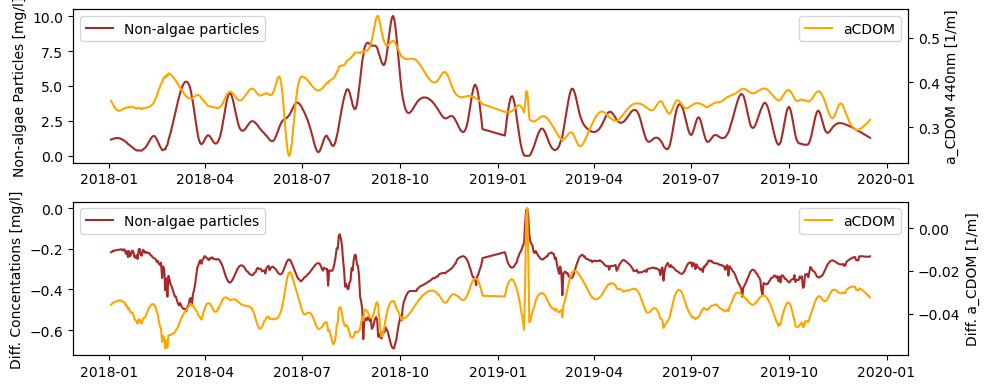

In [46]:
## plot the inversion timeseries!
varList = ['NAP [mg/l]', 'ag(440) [1/m]']
invList = ['C_ism', 'C_Y']
varNameList = ['Non-algae particles',  'aCDOM']
colorList = ['brown', 'orange']

yearStart = 2018
yearEnd = 2019
years = np.asarray([a.year for a in iop_insitu.index])
IDyear = np.logical_and(years>=yearStart, years<=yearEnd)

fig, ax = plt.subplots(nrows=2, figsize=(10, 4))
for v,vn, col, ivn in zip(varList, varNameList, colorList, invList):
    if 'NAP' in v:
        ax[0].plot(iop_insitu.index[IDyear], inv_iop[ivn].loc[IDyear], '-', label=vn, color=col)
        ax[1].plot(iop_insitu.index[IDyear], (inv_iop[ivn].loc[IDyear].values -iop_insitu[v].loc[IDyear].values), '-', label=vn, color=col)
    else:
        ax0_ = ax[0].twinx()
        ax0_.plot(iop_insitu.index[IDyear], inv_iop[ivn].loc[IDyear], '-', label=vn, color=col)
        ax1_ = ax[1].twinx()
        ax1_.plot(iop_insitu.index[IDyear], (inv_iop[ivn].loc[IDyear].values -iop_insitu[v].loc[IDyear].values), '-', label=vn, color=col)
ax[0].legend(loc='upper left')
ax0_.legend(loc='upper right')
ax[1].legend(loc='upper left')
ax1_.legend(loc='upper right')
# ax.set_xlabel('Year')
ax[0].set_ylabel('Non-algae Particles [mg/l]')
ax[1].set_ylabel('Diff. Concentations [mg/l]')
ax0_.set_ylabel('a_CDOM 440nm [1/m]')
ax1_.set_ylabel('Diff. a_CDOM [1/m]')
# ax[1].set_ylim((-50,50))
fig.tight_layout()
plt.show()

### Simulation spectra - and estimation of start values

#### CHIME 5nm approximation

In [114]:
## 5nm CHIME approximation
sim_path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\dalaro-2\\"
fname = ['AQUATIME_D2.1.0_RD-dalaro_daily_fluo-chime-simulated-RrsNoGlint_v0.4.csv']
dat = pd.read_csv(sim_path + fname[0], header=0)
wlstr = [str(wl) for wl in dat.columns.values if not wl in ['date', 'QWIP']]
wavelengths = np.asarray([float(wl) for wl in wlstr])

#### CHIME center wavelengths
Switch between AQUATIME and HEATWISE paths manually!

In [17]:
## CHIME center wavelengths
# sim_path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\bio-optics_forward\\"
sim_path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
fname = os.listdir(sim_path)
fname = [fn for fn in fname if fn.startswith('SimRrs_InsituForward') and 'CHIMEbands' in fn and regionName.split('-')[0] in fn]
# dat = pd.read_csv(sim_path + fname[0], sep='\t')
boo = pd.read_csv(sim_path + fname[0], sep='\t')
# wlstr = [str(wl) for wl in wavelengths]
wl_boo = [float(wl) for wl in boo.columns.values]
wlstr_boo = [str(wl) for wl in boo.columns.values]

# pred_chl_tot, pred_acdom, pred_TSS = bandratioIOPprediction.predict_start_values_allSensors(dat[wlstr].values,
#                                                                                             wavelengths,
#                                                                                             outlierRemoval=True)

### Inversion results
Switch between AQUATIME and HEATWISE data manually!

In [10]:
## Inversion results: AQUATIME
# path =  "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\"

### Inversion Input: bio_optics forward simulations from insitu input ###
## Model with 2 Phyto-components: C_0, C_3 (Brown group, Cyano blue), offset on, no fluorescence
# fList = ['inverted_IOP_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0_allOWTs_withStartValueEstimNo.txt']
# fList_estim = ['inverted_IOP_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0_allOWTs_withStartValueEstim2.txt']
## Model with 3 Phyto-components: C_0, C_3, C_6 (Brown group, Cyano blue, Dinofl.), offset on, no fluorescence
# fList = ['inverted_IOP_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0_allOWTs_P036.txt']
## Model with 3 Phyto-components: C_0, C_3, C_6 (Brown group, Cyano blue, Dinofl.), offset off, fluorescence chl + phycocyanin
# fList = ['inverted_IOP_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0_allOWTs_P036_noOffset_2Fluor.txt']
# simList = ['inverted_Sim_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0_allOWTs_P036_noOffset_2Fluor.txt']
# fList = ['inverted_IOP_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_dalaro_dalaro_v0_Inv0_allOWTs_P0136_noOffset_2Fluor.txt']

### Inversion Input: MOMO spectra
# fList = ['inverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_dalaro-2_allOWTs_P036_Offset_2Fluor.txt']
# simList = [fn.replace('inverted_IOP', 'inverted_Sim') for fn in fList]

### Inversion results: HEATWISE example
path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\"
fList = ['inverted_IOP_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_CHIMEbands_v0.3_allOWTs_P012356.txt']
# ## Phytoplankton groups are indicated at the end of filename: P0, P06, P036, P03, P023, P0235, P012356, HEREONgold-> C5 is gold algae
simList = [fn.replace('inverted_IOP', 'inverted_Sim') for fn in fList]


inv_iop = pd.read_csv(path + fList[0], header=0)
# inv_iop_start = pd.read_csv(path + fList_estim[0], header=0)
inv_sim = pd.read_csv(path + simList[0], header=0)
sim_wl = np.asarray([float(a) for a in inv_sim.columns.values if not a == 'date'])


### Analysis influence of start values
Start values are too bad to have a positive impact on the retrieval!

In [32]:
def simple_analysis_plot_byDict(ddict):
    fig, ax = plt.subplots(ncols=3, figsize=(10, 3))
    bins = np.arange(0, 14, 0.5)
    if 'hist' in ddict.keys():
        for key in ddict['hist'].keys():
            ax[0].hist(ddict['hist'][key], bins, label=key, alpha=0.5)
        ax[0].legend()
    if 'diff' in ddict.keys():
        ax[1].plot(ddict['diff']['d1'], ddict['diff']['d2'], '+')
        thisdiff = ddict['diff']['d1'] - ddict['diff']['d2']
        ax[2].hist(thisdiff, 30)
    fig.tight_layout()
    plt.show()

In [39]:
# plotDict = {
#     'hist' : {
#         'Insitu': iop_insitu['Chlg [µg/l]'].values,
#         'Lin. Estim Chl': pred_chl_tot,
#         'Inv Chl': inv_iop['C_phy'],
#         'Inv Start Chl': inv_iop_start['C_phy']
#     },
#     'diff': {
#         'd1' : inv_iop['C_phy'].values,
#         'd2' : inv_iop_start['C_phy'].values
#     }
# }
plotDict = {
    'hist' : {
        'Insitu': iop_insitu['NAP [mg/l]'].values,
        'Lin. Estim TSS': pred_TSS,
        'Inv ISM': inv_iop['C_ism'],
        'Inv Start ISM': inv_iop_start['C_ism']
    },
    'diff': {
        'd1' : inv_iop['C_ism'].values,
        'd2' : inv_iop_start['C_ism'].values
    }
}

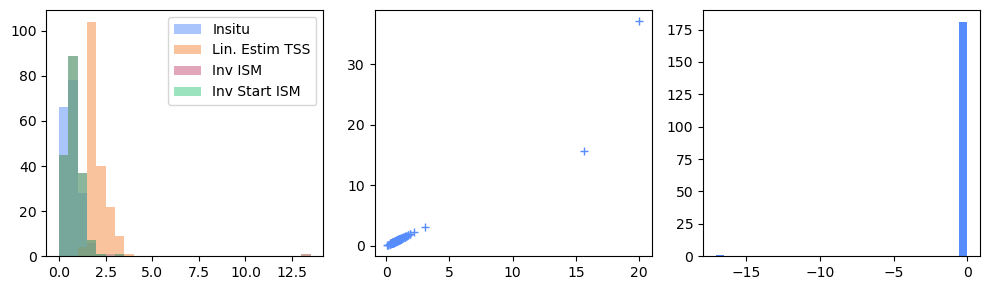

In [40]:
simple_analysis_plot_byDict(plotDict)


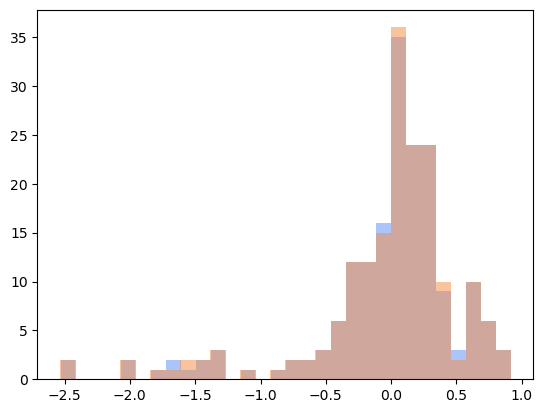

In [36]:
plt.hist(inv_iop['C_phy'].values - iop_insitu['Chlg [µg/l]'].values, 30, label='default', alpha=0.5)
plt.hist(inv_iop_start['C_phy'].values - iop_insitu['Chlg [µg/l]'].values, 30, label='start', alpha=0.5)
plt.show()

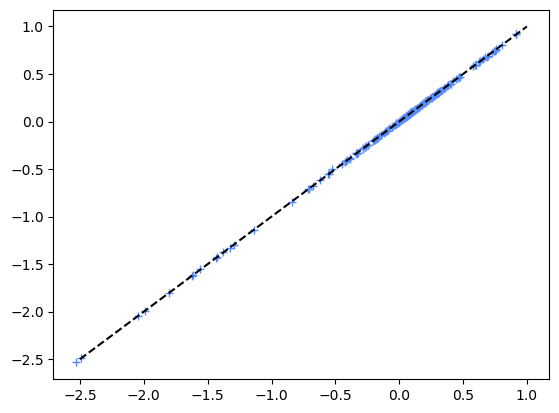

In [38]:
plt.plot(inv_iop['C_phy'].values - iop_insitu['Chlg [µg/l]'].values, inv_iop_start['C_phy'].values - iop_insitu['Chlg [µg/l]'].values, '+')
plt.plot((-2.5, 1), (-2.5, 1.), 'k--')
plt.show()

### Analysis Phytoplankton groups

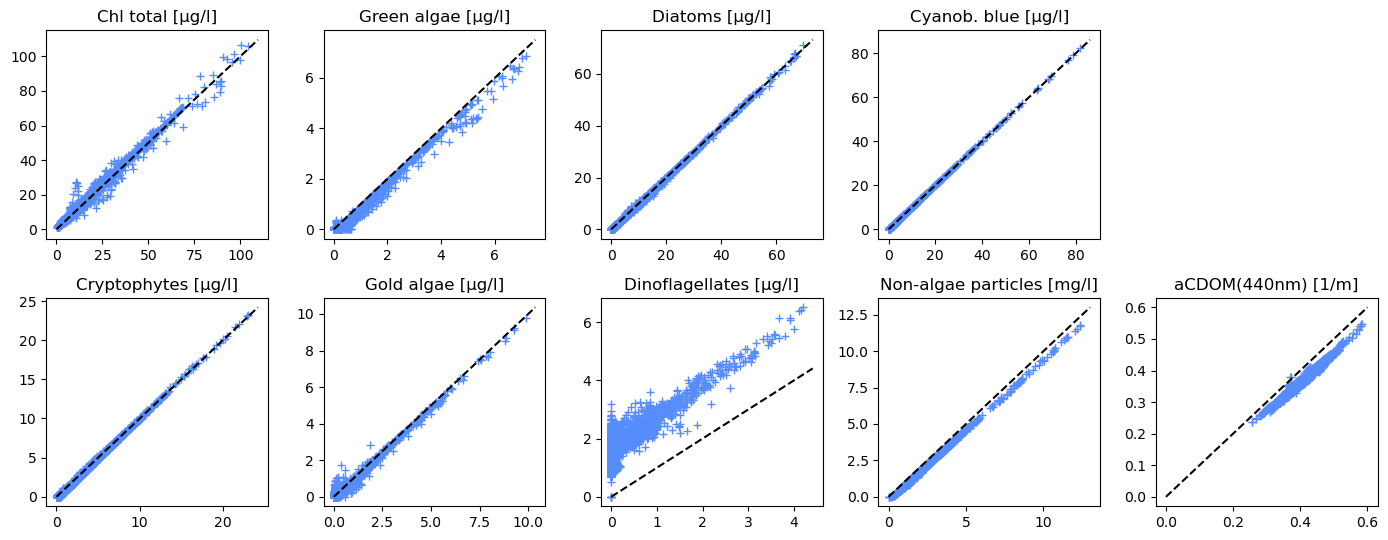

In [11]:
insituList= ['Chlg [µg/l]',  'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]', 'Ccry [µg/l]',  'Cgold [µg/l]', 'Cdino [µg/l]', 'NAP [mg/l]', 'ag(440) [1/m]']
invList = ['C_phy', 'C_1', 'C_0', 'C_3', 'C_4', 'C_2', 'C_5', 'C_6', 'C_ism', 'C_Y']
titleList = ['Chl total [µg/l]', 'Green algae [µg/l]', 'Diatoms [µg/l]', 'Cyanob. blue [µg/l]', 'Cyanob. red [µg/l]', 'Cryptophytes [µg/l]',  'Gold algae [µg/l]', 'Dinoflagellates [µg/l]', 'Non-algae particles [mg/l]', 'aCDOM(440nm) [1/m]' ]

Nx, Ny = (5, 2)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(14, 5.5))
ix, iy = (0,0)
for ins, inv, tit in zip(insituList, invList, titleList):
    if np.any(inv_iop[inv].values>0):
        if '+' in ins:
            ins1, ins2 = ins.split(' + ')
            ax[iy, ix].plot(iop_insitu[ins1].values +iop_insitu[ins1].values, inv_iop[inv].values, '+')
        else:
            ax[iy, ix].plot(iop_insitu[ins].values, inv_iop[inv].values, '+')
        xlim = ax[iy, ix].get_xlim()
        ax[iy, ix].plot((0, xlim[1]), (0, xlim[1]), 'k--')
        ax[iy, ix].set_title(tit)
        # ax[iy, ix].set_ylabel(inv)
        # ax[iy, ix].set_xlabel(ins)
    else:
        ax[iy, ix].axis('off')
    ix +=1
    if ix == Nx:
        ix=0
        iy+=1
fig.tight_layout()
plt.show()

In [12]:
## spectral error
## Errors of Reconstructed spectra
def setup_spectral_error_df(Xtrain, X_projected):
    SpectralErrorDF = pd.DataFrame()

    rMAE = np.zeros(Xtrain.shape[0])
    sam = np.zeros(Xtrain.shape[0])

    rMAE = np.sqrt(np.sum((Xtrain - X_projected) ** 2, axis=1)) / np.sum(Xtrain, axis=1)
    sqrtsum2_orig = np.sqrt(np.sum(Xtrain ** 2, axis=1))
    sqrtsum2_inv = np.sqrt(np.sum(X_projected ** 2, axis=1))
    sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)
    sam = np.arccos(sam)

    sam *= 180. / np.pi
    SpectralErrorDF['rMAE'] = rMAE
    SpectralErrorDF['SAM'] = sam
    SpectralErrorDF['absErr'] = np.sum(np.abs(X_projected - Xtrain), axis=1)

    return SpectralErrorDF

In [95]:
inv_sim.columns.values

<ArrowStringArray>
['400.0', '405.0', '410.0', '415.0', '420.0', '425.0', '430.0', '435.0',
 '440.0', '445.0', '450.0', '455.0', '460.0', '465.0', '470.0', '475.0',
 '480.0', '485.0', '490.0', '495.0', '500.0', '505.0', '510.0', '515.0',
 '520.0', '525.0', '530.0', '535.0', '540.0', '545.0', '550.0', '555.0',
 '560.0', '565.0', '570.0', '575.0', '580.0', '585.0', '590.0', '595.0',
 '600.0', '605.0', '610.0', '615.0', '620.0', '625.0', '630.0', '635.0',
 '640.0', '645.0', '650.0', '655.0', '660.0', '665.0', '670.0', '675.0',
 '680.0', '685.0', '690.0', '695.0', '700.0', '705.0', '710.0', '715.0',
 '720.0', '725.0', '730.0', '735.0', '740.0', '745.0', '750.0', '755.0',
 '760.0', '765.0', '770.0', '775.0', '780.0', '785.0', '790.0', '795.0',
 '800.0', '805.0', '810.0', '815.0', '820.0', '825.0', '830.0', '835.0',
 '840.0', '845.0',  'date']
Length: 91, dtype: str

In [98]:
# spectralErr = setup_spectral_error_df(dat[wlstr[:len(sim_wl)]].values, inv_sim.values) # bio_optics forward at CHIME
spectralErr = setup_spectral_error_df(dat[wlstr[:len(sim_wl)]].values, inv_sim.iloc[:,:-1].values) # MOMO at 5nm steps

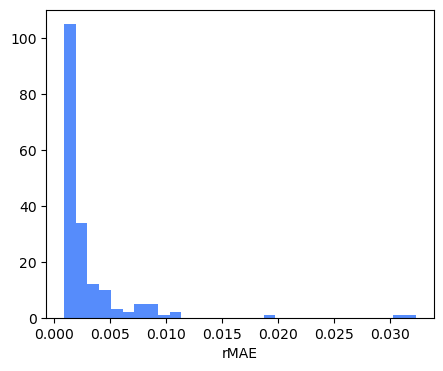

In [99]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
ax.hist(spectralErr['rMAE'], 30)
ax.set_xlabel('rMAE')
plt.show()

#### Distribution of Spectral Errors
Check all phytoplankton group combinations, which were inverted.
Hopefully, the fit gets better with more components.

In [19]:
path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\"

phytoGroupingString = ['P0', 'P06', 'P036', 'P03', 'P023', 'P0235', 'P012356']
spectralErrDict = {}
for pg in phytoGroupingString:
    fList = ['inverted_IOP_bio_optics_HEREONfull_SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_CHIMEbands_v0.3_allOWTs_'+pg+'.txt']
    # ## Phytoplankton groups are indicated at the end of filename: P0, P06, P036, P03, P023, P0235, P012356, HEREONgold-> C5 is gold algae
    simList = [fn.replace('inverted_IOP', 'inverted_Sim') for fn in fList]


    inv_iop = pd.read_csv(path + fList[0], header=0)
    # inv_iop_start = pd.read_csv(path + fList_estim[0], header=0)
    inv_sim = pd.read_csv(path + simList[0], header=0)
    sim_wl = np.asarray([float(a) for a in inv_sim.columns.values if not a == 'date'])

    spectralErrDict[pg] = setup_spectral_error_df(boo[wlstr_boo[:len(sim_wl)]].values, inv_sim.values) # bio_optics forward at CHIME


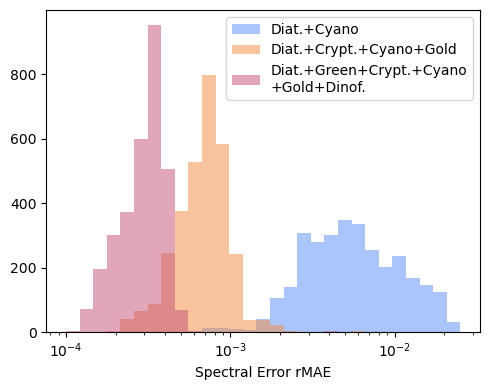

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
phytoGroupingString = ['P03', 'P0235', 'P012356']
phytoList = ['Diat.+Cyano', 'Diat.+Crypt.+Cyano+Gold', 'Diat.+Green+Crypt.+Cyano\n+Gold+Dinof.']
b = np.logspace( -4., np.log10(0.025), 30)
for pg, pgn in zip(phytoGroupingString, phytoList):
    ax.hist(spectralErrDict[pg]['rMAE'], b, label=pgn, alpha=0.5)
ax.legend()
ax.set_xscale('log')
ax.set_xlabel('Spectral Error rMAE')
fig.tight_layout()
plt.show()

### Find best GLORIA

In [166]:
fnameG = "E:\Documents\projects\EnsAD\insitu_data\GLORIA\GLORIA_Rrs_mean.csv"
gloria_rrs = pd.read_csv(fnameG, header=0, sep=',')
wlstr_Gloria = [a for a in gloria_rrs.columns.values if a.startswith('Rrs')]
wl_Gloria = np.asarray([float(a.split('_')[-1]) for a in wlstr_Gloria])

np.int64(5135)

In [206]:
## GLORIA data: find the in-situ spectrum based on Chlg, NAP, ag(440)
# Chl, TSM, CDOM: from data to be studied and compared to the GLORIA in-situ spectra
def find_GLORIA_examples(Chl, TSM, CDOM):
    fnameGLORIA = "E:\Documents\projects\EnsAD\insitu_data\GLORIA\GLORIA_meta_and_lab.csv"
    gloria_iop = pd.read_csv(fnameGLORIA, sep=',', header=0)
    fnameG = "E:\Documents\projects\EnsAD\insitu_data\GLORIA\GLORIA_Rrs_mean.csv"
    gloria_rrs = pd.read_csv(fnameG, header=0, sep=',')
    wlstr_Gloria = [a for a in gloria_rrs.columns.values if a.startswith('Rrs')]
    wl_Gloria = np.asarray([float(a.split('_')[-1]) for a in wlstr_Gloria])
    ID = np.sum(np.logical_not(np.isnan(gloria_rrs[wlstr_Gloria].values)), axis=1) > 0
    gloria_iop = gloria_iop.loc[ID,:]
    gloria_rrs = gloria_rrs.loc[ID,:]
    print(gloria_iop.shape, gloria_rrs.shape)

    # find all examples within the insitu data range
    ID_chla = np.logical_and(gloria_iop['Chla'].values > np.min(Chl), gloria_iop['Chla'].values < np.max(Chl))
    ID_chla_phaeo = np.logical_and(gloria_iop['Chla_plus_phaeo'].values > np.min(Chl), gloria_iop['Chla_plus_phaeo'].values < np.max(Chl))
    ID_TSS = np.logical_and(gloria_iop['TSS'].values > np.min(TSM), gloria_iop['TSS'].values < np.max(TSM))
    IDvalid = np.logical_not(np.isnan(gloria_iop['aCDOM440'].values))
    ID_CDOM = np.logical_and(IDvalid, np.logical_and(gloria_iop['aCDOM440'].values > np.min(CDOM), gloria_iop['aCDOM440'].values < np.max(CDOM)))

    ## find the examples within all ranges
    ID = np.logical_and( np.logical_or(ID_chla, ID_chla_phaeo), ID_TSS)
    ID2 = np.logical_and(ID, ID_CDOM)

    errorArr = None
    indexArr = None
    if np.sum(ID2)> 0:
        print(np.sum(ID2), 'examples within GLORIA based on the given insitu ranges.')
        gloria_iop = gloria_iop.loc[ID2,:]
        gloria_rrs = gloria_rrs.loc[ID2,:]
        print(gloria_iop.shape, gloria_rrs.shape)

        IDchl = np.logical_and(np.isnan(gloria_iop['Chla'].values) , np.logical_not(np.isnan(gloria_iop['Chla_plus_phaeo'])))
        print(np.sum(IDchl))
        chl = gloria_iop['Chla'].values.copy()
        chl[IDchl] = np.asarray(gloria_iop['Chla_plus_phaeo'].values[IDchl])
        gloria_iop['Chla'] = chl

        errorArr = np.zeros(gloria_iop.shape[0])
        indexArr = np.zeros(gloria_iop.shape[0])
        for i, (gchl, gtss, gcdom) in enumerate(gloria_iop[['Chla', 'TSS', 'aCDOM440']].values):
            # print(gchl, gtss, gcdom)
            testV = np.abs(Chl - gchl)/gchl + np.abs(TSM-gtss)/gtss + np.abs(CDOM-gcdom)/gcdom
            errorArr[i] = np.min(testV)
            indexArr[i] = np.argmin(testV)

    return errorArr, indexArr, gloria_rrs, gloria_iop



In [258]:
errorArr, indexArr, gloria_rrs, gloria_iop = find_GLORIA_examples(Chl=iop_insitu['Chlg [µg/l]'].values, TSM=iop_insitu['TSPM [mg/l]'].values, CDOM=iop_insitu['ag(440) [1/m]'].values)

(2437, 64) (2437, 553)
62 examples within GLORIA based on the given insitu ranges.
(62, 64) (62, 553)
4


[ 49.  44. 177. 121.]
[0.11507523 0.10650815 0.08301411 0.12893223]
121


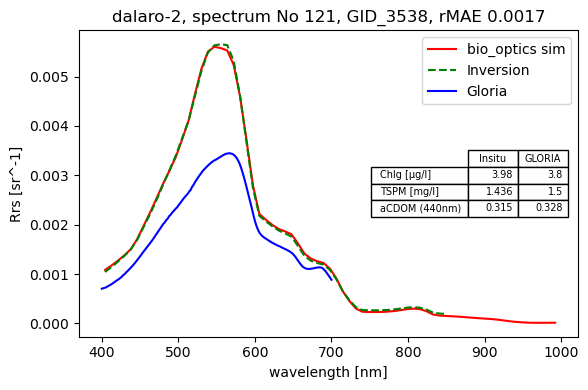

In [268]:
## min relative difference in concentration
# IDgloria = errorArr == np.min(errorArr)
IDgloria = errorArr < np.percentile(errorArr, 5)
print(indexArr[IDgloria])
print(errorArr[IDgloria])
Ngloria = 3
Ni = int(indexArr[IDgloria][Ngloria])
print(Ni)
insituList2 = insituList.copy()
[insituList2.append(a) for a in ['TSPM [mg/l]']]
# print(iop_insitu[insituList2].iloc[Ni,:])
invList2 = invList.copy()
[invList2.append(a) for a in ['offset']]
# print(inv_iop[invList2].iloc[Ni,:])
# print(gloria_iop[['Chla', 'TSS', 'aCDOM440']].loc[IDgloria,:].values[Ngloria,:])

fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(wavelengths, dat[wlstr].iloc[Ni,:].values, 'k-', label='Original')
# plt.plot(wavelengths, dat[wlstr].iloc[Ni,:].values, 'k-', label='MOMO sim')
ax.plot(wl_boo, boo.iloc[Ni,:].values, 'r-', label='bio_optics sim')
# plt.plot(sim_wl, inv_sim.iloc[Ni,:-1].values, 'g--', label='Inversion')
ax.plot(sim_wl, inv_sim.iloc[Ni,:].values, 'g--', label='Inversion')
ax.plot(wl_Gloria, gloria_rrs[wlstr_Gloria].loc[IDgloria,:].values[Ngloria,:], 'b-', label='Gloria')

col_labels=['Insitu','GLORIA']
row_labels=['Chlg [µg/l]','TSPM [mg/l]', 'aCDOM (440nm)']
tableDF = pd.DataFrame()
tableDF['Insitu'] = np.round(iop_insitu[['Chlg [µg/l]', 'TSPM [mg/l]', 'ag(440) [1/m]']].iloc[Ni,:].values, 3)
tableDF['GLORIA'] = np.round(gloria_iop[['Chla', 'TSS', 'aCDOM440']].loc[IDgloria,:].values[Ngloria,:],3)
table_vals= tableDF.values
# the rectangle is where I want to place the table
the_table = ax.table(cellText=table_vals,
                  colWidths = [0.1]*3,
                  rowLabels=row_labels,
                  colLabels=col_labels,
                  loc='center right')
# plt.text(12,3.4,'Table Title',size=8)

ax.set_title(regionName + ', spectrum No ' + str(Ni) + ', ' + gloria_iop['GLORIA_ID'].loc[IDgloria].values[Ngloria]+ ', rMAE '+ str(np.round(spectralErr['rMAE'].iloc[Ni], 4)))
ax.legend()
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel('Rrs [sr^-1]')
fig.tight_layout()
plt.show()

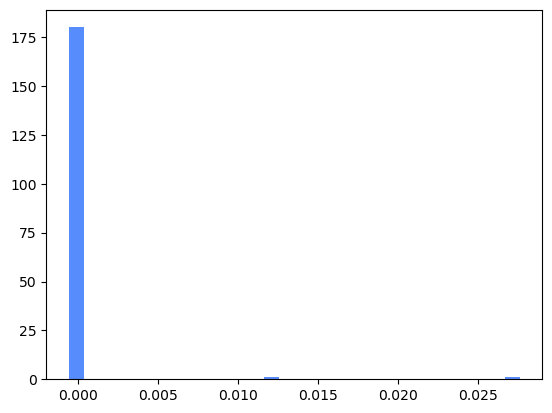

In [107]:
plt.hist(inv_iop.offset.values, 30)
plt.show()